In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [ ]:
df = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

In [ ]:
df.shape

(23479, 505)

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
count,2.347900e+04,23479.000000,23479.000000,23479.0,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,0.0
mean,1.009742e+11,869.160015,372.191661,500.0,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,...,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743,NaN
std,5.715472e+10,572.905756,470.391688,0.0,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,...,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307,NaN
min,2.890276e+06,0.000000,10.000000,500.0,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,...,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000,NaN
25%,5.156311e+10,373.000000,64.000000,500.0,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,NaN
50%,1.014553e+11,810.000000,172.000000,500.0,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,NaN
75%,1.502418e+11,1341.000000,483.000000,500.0,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,NaN
max,2.000107e+11,1998.000000,3370.000000,500.0,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,...,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000,NaN


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0
504,23479


In [ ]:
df = df.drop(504, axis=1)

In [ ]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825
5,22773382,1310,61,500,14825,14820,14822,14824,14823,14823,...,14823,14823,14817,14820,14813,14819,14821,14820,14828,14822
6,26520366,1154,195,500,14824,14820,14818,14824,14820,14823,...,14816,14818,14820,14820,14823,14818,14824,14826,14821,14818
7,70574842,1904,31,500,14824,14820,14825,14823,14824,14826,...,14824,14820,14823,14824,14826,14824,14821,14824,14826,14820
8,73301918,1083,397,500,14824,14818,14823,14820,14828,14824,...,14822,14819,14824,14822,14821,14820,14819,14820,14823,14824
9,74388134,1654,391,500,14825,14824,14821,14820,14821,14824,...,14817,14819,14823,14824,14820,14818,14816,14823,14822,14816


In [ ]:
SIGNAL_LEN = 500  # длина сигнала
BASELINE_SAMPLES = 50   # первые отсчёты — бейзлайн

In [ ]:
def process_signal(signal):  # обработка сигнала
    signal = np.array(signal)

    # бейзлайн
    baseline = signal[:BASELINE_SAMPLES].mean()
    s = signal - baseline  # сигнал колеблется около нуля, импульс становится более выделенным

    # переворачиваем импульс наверх (был направлен вниз)
    s = -s

    # амплитуда - максимальное отклонение от бейзлайна
    amp = s.max()

    if amp <= 0:
        return None  # защита от шумовых значений

    # начало импульса: 40% от амплитуды - более устойчиво к шуму
    thr = 0.4 * amp
    idx_start = np.argmax(s > thr) # первый индекс где сигнал превышает порог

    # ограничим окно импульса - берём только физически значимую часть
    window = s[idx_start:idx_start + 200]

    # интегралы
    total_integral = window.sum()  # общая энергия импульса
    tail_integral = window[50:].sum()  # энергия хвоста для гамма лучей будет маленьким т.е. быстрое затухание, а для нейтронов большим.

    psd = tail_integral / total_integral if total_integral != 0 else 0  # ключевой признак для разделения частиц Pulse Shape Discrimination

    # время высвечивания (до 10% амплитуды)
    decay_idx = np.where(window < 0.1 * amp)[0] #[0] потому что кортеж
    decay_time = decay_idx[0] if len(decay_idx) > 0 else len(window)  # временная характеристика хвоста

    return amp, total_integral, psd, decay_time

In [ ]:
#Создание признаков для всех сигналов
features = []
indices = []

for i, row in df.iterrows(): #ндекс строки, сама строка как Series
    signal = row[-SIGNAL_LEN:]  # берём последние 500 столбцов
    res = process_signal(signal)

    if res is not None:
        features.append(res)
        indices.append(i)

features = pd.DataFrame(features,
    columns=["amplitude", "integral", "psd", "decay_time"]
)

In [ ]:
#Нормализация признаков
scaler = StandardScaler()  # нормировка
X_scaled = scaler.fit_transform(features)

In [ ]:
#визуализация кластеров в 2D-пространстве.
def plot_pca_clusters(X_pca, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(X_pca[:, 0], #веса фич в новых осях подобраны так, чтобы объяснял максимально возможную изменчивость данных
        X_pca[:, 1],
        c=labels,
        s=5
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def clustering_metrics(X, labels): #вычисляет метрики качества кластеризации.
    mask = labels != -1 # -1 — это выбросы в DBSCAN

    if len(set(labels[mask])) < 2:
        return np.nan, np.nan

    sil = silhouette_score(X[mask], labels[mask]) #насколько объекты внутри кластера похожи друг на друга и отличаются от других кластеров.
    ch = calinski_harabasz_score(X[mask], labels[mask]) #отношение межкластерного расстояния к внутрикластерному.

    return sil, ch

In [ ]:
def fit_cluster_model(model, X): #обобщённая функция для обучения кластерной модели.
    labels = model.fit_predict(X)
    return labels

In [ ]:
def normalize_labels(labels): #привести метки кластеров к стандартной нумерации 0,1,2.
    unique = np.unique(labels)
    mapping = {old: new for new, old in enumerate(unique)}  # словарь [(0, -1), (1, 0), (2, 1), (3, 2)] {-1: 0, 0: 1, 1: 2, 2: 3}
    return np.array([mapping[l] for l in labels]) # было [-1, 0, -1, 1, 2, 0, 1, 2] стало [0, 1, 0, 2, 3, 1, 2, 3]

In [ ]:
pca = PCA(n_components=2)  # метод главных компонент Берёт все признаки (их может быть десятки) и проецирует их в 2D-пространство, сохраняя максимум вариации.
X_pca = pca.fit_transform(X_scaled)

In [ ]:
def pca_cut(X_pca, axis=0, threshold=0.0): #PCA cut разделяет все точки на два кластера одной прямой, перпендикулярной оси PC1.
    return (X_pca[:, axis] > threshold).astype(int)  #бинаризация сигналов по одной главной компоненте. Если значение первой компоненты больше порога → 1, иначе → 0.

In [ ]:
def kmeans_func(X_pca, n_clusters=2):
    model = KMeans(n_clusters=n_clusters, random_state=42)
    return fit_cluster_model(model, X_pca)

In [ ]:
def dbscan_func(X_pca, eps=0.5, min_samples=20):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    return fit_cluster_model(model, X_pca)

In [ ]:
methods = {
    "PCA cut": lambda X: pca_cut(X),
    "KMeans": lambda X: kmeans_func(X),
    "DBSCAN": lambda X: dbscan_func(X)
}


PCA cut         | Silhouette: 0.3591

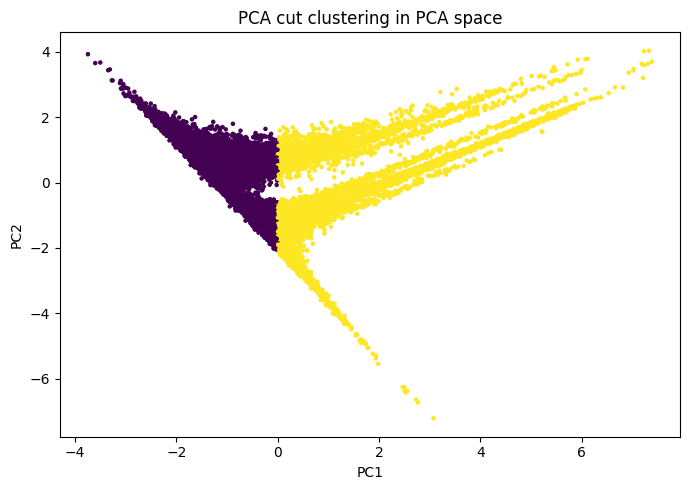

KMeans          | Silhouette: 0.4236

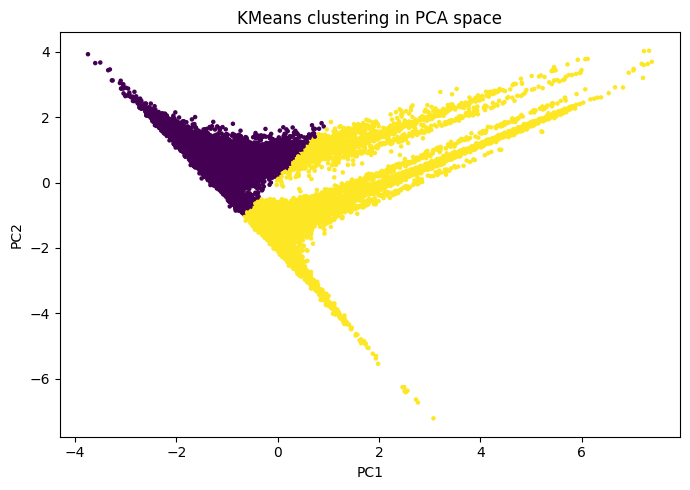

DBSCAN          | Silhouette: nan

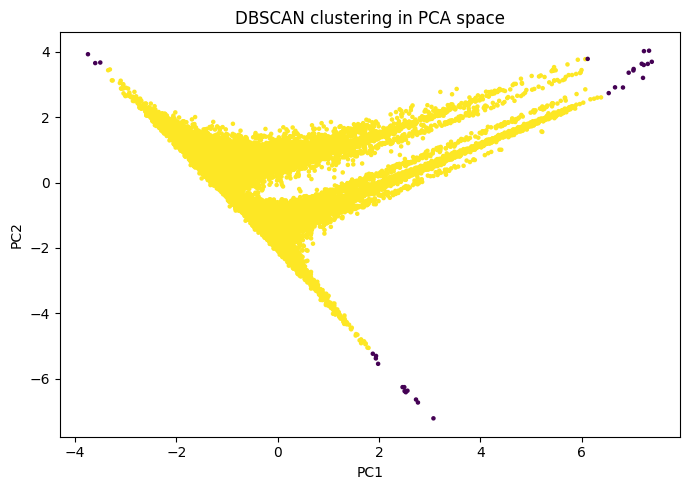

In [ ]:
results = {}

for name, method in methods.items():
    labels = method(X_pca)
    sil, ch = clustering_metrics(X_pca, labels)

    results[name] = {
        "Silhouette": sil
    }

    print(f"{name:15s} | Silhouette: {sil:.4f}")

    plot_pca_clusters(X_pca, labels, f"{name} clustering in PCA space")

    labels_norm = normalize_labels(labels)

    submission = pd.DataFrame({
        "index": indices,
        "cluster": labels_norm
    }).sort_values("index")

    submission.to_csv(f"submission_{name}.csv", index=False)